# PatchTST OHLCV forecasting -- HF PatchTSTModel replication of steven's task

`steven/src/models/patchtst.py` is a hand-rolled PatchTST-style transformer: it patches
the input (7-bar / 1-trading-day patches) and self-attends across patches, but does
**early channel fusion** -- all 7 feature channels are flattened together into one linear
patch embedding before any attention happens. It does not use the paper's channel-independence
design, and has no way to toggle channel-mixing on/off.

This notebook replicates steven's exact **task** (same data, same target parameterization,
same loss) with the real HF `PatchTSTModel` backbone instead, which *does* implement
channel-independent patching (each channel patched/embedded separately) with an optional
`channel_attention` sublayer to let channels cross-inform each other. That gives us a lever
steven's architecture structurally can't offer: compare channel-independent vs.
channel-mixing on the identical task/loss/data.

**Merged notebook**: this replaces the two previously-separate
`train_patchtst_hf_channel_attention_{True,False}.ipynb` notebooks, which differed only in
one config line (`CHANNEL_ATTENTION`) and otherwise duplicated ~20 cells of identical code.
Running this notebook top to bottom now trains **both** `channel_attention` settings in one
pass (see the `EXPERIMENT` config cell and the training loop below), writes one metrics JSON
per setting to `steven/comparison_metrics/`, and commits + pushes both at the end.

**Kept identical to steven's setup, for a fair comparison:**
- Data: `steven/data/spy_ohlcv_1h.parquet`, same train/val/test date splits (`steven/src/data_pipeline.py`).
- Target parameterization: anchored log-returns per horizon bar (`open_ret`, `body_ret`,
  `upper_wick`, `lower_wick`) + `log_volume_norm`, 3 bars ahead (`HORIZON=3`), reused directly
  from `steven/src/data_pipeline.py`/`steven/src/losses.py` (`build_dataset`, `unpack_y`,
  `weighted_mse_loss`, `reconstruct_prices`, `reconstruct_volume`) -- no reimplementation.
- Loss: the same deterministic weighted MSE (see `EXPERIMENT["loss_weights"]` below), same
  bounded output (`tanh`/`sigmoid` x `MAX_LOG_RETURN`) applied to the head's raw output before
  the loss -- this notebook's model produces the exact same 15-dim output shape/bounding as
  steven's, so `weighted_mse_loss`/`unpack_y` are reused unmodified.
- Patch structure: `patch_length=7`, `patch_stride=7` (non-overlapping, one trading day per
  patch), matching steven's `PATCH_LEN=7`.
- Training hyperparameters: `lr=6e-4`, `weight_decay=1e-4`, `batch_size=512`, 20 epochs x
  20,000 resampled windows/epoch -- from `steven/configs/patchtst.yaml`.

**One deliberate simplification**: steven's model trains on a variable-context curriculum
(2-10 trading days, resampled per window). HF `PatchTSTModel` patchifies a single fixed
`context_length` per model, so this notebook fixes `context_length=MAX_CONTEXT=70` (10 trading
days, steven's longest curriculum option) rather than replicating the curriculum -- most
directly comparable to steven's own "long" context bucket in `steven/outputs/metrics.json`,
not his "overall" (mixed-length) numbers.

**Deferred**: the long-only limit-order backtest (`steven/src/evaluate.py`'s `run_backtest`)
is not implemented here -- per instruction, that comes after we've confirmed which
architecture/`channel_attention` setting is actually better on the forecasting metrics.


## Colab setup

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv


name, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB


In [2]:
import os

REPO_URL = "https://github.com/WoodyChang21/ECE1508_GenAI.git"
BRANCH = "patchtst_ohlcv_mse"
REPO_DIR = "/content/ECE1508_GenAI"   # absolute path -- see note below

if not os.path.isdir(REPO_DIR):
    !git clone -b {BRANCH} {REPO_URL} {REPO_DIR}
else:
    # git -C targets REPO_DIR explicitly rather than `cd X && ...`, so this is correct
    # regardless of the kernel's current working directory when the cell reruns.
    !git -C {REPO_DIR} pull

# Absolute path, not "ECE1508_GenAI": os.path.isdir("ECE1508_GenAI") above is checked
# relative to the CURRENT working directory -- on a second run of this cell (after the
# %cd below already moved the kernel into /content/ECE1508_GenAI), that relative check
# looks for /content/ECE1508_GenAI/ECE1508_GenAI, finds nothing, and silently clones a
# second, nested copy of the repo inside the first one instead of pulling it.
%cd {REPO_DIR}


Already up to date.
/content/ECE1508_GenAI


In [3]:
# torch is preinstalled on Colab; transformers is the one addition vs. steven's own
# colab_train.ipynb (steven's hand-rolled model has no library dependency for this).
!pip install -q transformers mplfinance pyyaml


In [4]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## Imports and config

`sys.path` is set up so `from src.data_pipeline import ...` / `from src.losses import ...`
resolve the same way steven's own scripts import them (both insert `steven/` itself onto
the path, not the repo root -- see `steven/src/train_patchtst.py`).

`EXPERIMENT` describes *this run* -- it's what gets echoed into each output JSON's
`"experiment"` block and is the thing to paste into `docs/experiments.md`'s row when logging
the result, so the doc and the actual run config can't drift apart. Update `name`/`description`
each time this notebook is repurposed for a different target/volume/loss variant (per the
experiment ladder: fused-head parity check -> drop volume -> raw-price+volume ->
raw-price-no-volume -> head comparison).


In [5]:
import sys, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from transformers import PatchTSTConfig, PatchTSTModel

# Normalise cwd to the repo root regardless of whether this notebook is opened from
# within steven/ (local Jupyter) or the repo root (Colab, after the clone cell above).
if os.path.basename(os.getcwd()) == 'steven':
    os.chdir('..')
sys.path.insert(0, 'steven')

from src.data_pipeline import (
    build_dataset, extract_arrays, WindowSampler, build_window,
    reconstruct_prices, reconstruct_volume,
    MAX_CONTEXT, HORIZON, N_FEATURE_CHANNELS, MAX_LOG_RETURN,
)
from src.losses import weighted_mse_loss, unpack_y

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

DATA_PATH = 'steven/data/spy_ohlcv_1h.parquet'

# -- Describes this run -- echoed into every output JSON and comparison_metrics/ filename.
# "name" -> comparison_metrics/{name}-channel_attention_{false,true}.json
EXPERIMENT = {
    "name": "hf_patchtst_fused_head",
    "description": (
        "HF PatchTST model with channel_attention toggled. Same head as Steven's -- "
        "parity check before trying volume/target variants."
    ),
    "target": "anchored_log_return",
    "include_volume": True,
}

# -- Both settings are trained in one pass -- see the training loop below.
CHANNEL_ATTENTION_SETTINGS = [False, True]

# -- Model hyperparameters -- matched to steven/configs/patchtst.yaml's model block
# (d_model, nhead->num_attention_heads, num_layers->num_hidden_layers, dropout) so
# model capacity is comparable, not just the loss function.
D_MODEL      = 64
NUM_HEADS    = 4
NUM_LAYERS   = 3
DROPOUT      = 0.1
HEAD_DROPOUT = 0.0

# -- Patch structure -- matches steven's PATCH_LEN=7 (one trading day, non-overlapping).
PATCH_LEN    = 7
PATCH_STRIDE = 7

# -- Training hyperparameters -- from steven/configs/patchtst.yaml, unchanged.
LR                      = 6e-4
WEIGHT_DECAY            = 1e-4
BATCH_SIZE              = 512
MAX_EPOCHS              = 20
TRAIN_WINDOWS_PER_EPOCH = 20000
WINDOWS_PER_EVAL_SET    = 3000

# -- Loss weights -- from steven/configs/patchtst.yaml's loss block, unchanged.
EXPERIMENT["loss_weights"] = {"price": 1.0, "vol": 0.5}
W_PRICE = EXPERIMENT["loss_weights"]["price"]
W_VOL   = EXPERIMENT["loss_weights"]["vol"]

plt.rcParams['figure.figsize'] = (14, 4)

# -- Seed control -- reset again per setting in the training loop below, so both
# channel_attention runs get identical weight init, not just identical data order.
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'EXPERIMENT = {EXPERIMENT}')
print(f'SEED = {SEED}, CHANNEL_ATTENTION_SETTINGS = {CHANNEL_ATTENTION_SETTINGS}')


Device: cuda
EXPERIMENT = {'name': 'hf_patchtst_fused_head', 'description': "HF PatchTST model with channel_attention toggled. Same head as Steven's -- parity check before trying volume/target variants.", 'target': 'anchored_log_return', 'include_volume': True, 'loss_weights': {'price': 1.0, 'vol': 0.5}}
SEED = 0, CHANNEL_ATTENTION_SETTINGS = [False, True]


## Model

`PatchTSTModel` backbone (HF's real channel-independent-or-mixing encoder) + a
deterministic, bounded head that reproduces `steven/src/models/patchtst.py`'s
`forward()` output **exactly** -- same 15-dim layout, same `tanh`/`sigmoid` x
`MAX_LOG_RETURN` bounding -- so `weighted_mse_loss`/`unpack_y` from
`steven/src/losses.py` work unmodified on this model's output too.

`scaling=None`: steven's model has no per-window instance normalization (his
`open_ret`/`body_ret`/wicks are raw log-returns, and `log_volume_norm` is already
globally normalized once via train-split stats in `data_pipeline.py`). HF
`PatchTSTModel`'s default `scaling='std'` would add an extra per-window RevIN-style
normalization steven's model never sees -- disabled here so the comparison is about
the encoder architecture (channel-independent/mixing self-attention vs. steven's
early-fusion self-attention), not confounded by an extra normalization layer only
one side has.

Only channels 0-4 (`open_ret`, `body_ret`, `upper_wick`, `lower_wick`,
`log_volume_norm`) are ever forecast -- channels 5/6 (`time_gap_norm`,
`day_bar_index_norm`) are context-only inputs, matching steven's `PRICE_VOL_IDX`
restriction (his `y` target never includes them either).


In [6]:
class PatchTSTOHLCV(nn.Module):
    def __init__(self, config: PatchTSTConfig):
        super().__init__()
        self.backbone = PatchTSTModel(config)
        self.head = nn.Linear(5 * config.d_model, 15)   # 5 forecastable channels x d_model -> 15 targets
        self.dropout = nn.Dropout(config.head_dropout)

    def forward(self, past_values: torch.Tensor):
        base_out = self.backbone(past_values=past_values)
        pooled = base_out.last_hidden_state.mean(dim=2)      # mean-pool across patches: (bs, 7, d_model)
        pooled = self.dropout(pooled[:, :5, :])                # only the 5 forecastable channels: (bs, 5, d_model)
        raw = self.head(pooled.reshape(pooled.shape[0], -1))   # (bs, 15)

        price_raw = raw[:, :12].reshape(-1, 3, 4)
        # Exact same bounding as steven/src/models/patchtst.py's forward() -- keeps
        # this model's output space identical to steven's target space.
        open_ret   = MAX_LOG_RETURN * torch.tanh(price_raw[..., 0])
        body_ret   = MAX_LOG_RETURN * torch.tanh(price_raw[..., 1])
        upper_wick = MAX_LOG_RETURN * torch.sigmoid(price_raw[..., 2])
        lower_wick = MAX_LOG_RETURN * torch.sigmoid(price_raw[..., 3])
        price = torch.stack([open_ret, body_ret, upper_wick, lower_wick], dim=-1)

        volume = raw[:, 12:15]
        return price, volume


def build_model(channel_attention: bool) -> PatchTSTOHLCV:
    config = PatchTSTConfig(
        num_input_channels=N_FEATURE_CHANNELS,   # 7
        context_length=MAX_CONTEXT,              # 70 (fixed -- see markdown above)
        prediction_length=HORIZON,               # 3
        patch_length=PATCH_LEN,
        patch_stride=PATCH_STRIDE,
        d_model=D_MODEL,
        num_attention_heads=NUM_HEADS,
        num_hidden_layers=NUM_LAYERS,
        # transformers no longer has a single unified "dropout" field on PatchTSTConfig
        # (split into these four sub-layer dropouts, see modeling_patchtst.py) -- broadcasting
        # the same rate to all four keeps this equivalent to steven's single nn.Dropout(p=dropout).
        attention_dropout=DROPOUT,
        positional_dropout=DROPOUT,
        path_dropout=DROPOUT,
        ff_dropout=DROPOUT,
        head_dropout=HEAD_DROPOUT,
        channel_attention=channel_attention,
        scaling=None,   # see markdown above -- steven's model has no per-window normalization
    )
    return PatchTSTOHLCV(config)


## Data

Reuses `build_dataset`/`extract_arrays`/`WindowSampler`/`build_window` from
`steven/src/data_pipeline.py` unmodified -- same feature engineering, same
chronological train/val/test split boundaries as steven's own training run.

Built **once** here, shared across both `channel_attention` settings in the training loop
below -- neither the data nor the val/test windows depend on the setting being trained, so
there's no reason to reload/resample them twice.


In [7]:
df, bounds, stats = build_dataset(DATA_PATH)
feat, opens, closes = extract_arrays(df)

train_sampler = WindowSampler(*bounds['train'])
val_sampler   = WindowSampler(*bounds['val'])
test_sampler  = WindowSampler(*bounds['test'])

print(f'Train rows: {bounds["train"][1] - bounds["train"][0]:,}')
print(f'Val rows  : {bounds["val"][1] - bounds["val"][0]:,}')
print(f'Test rows : {bounds["test"][1] - bounds["test"][0]:,}')


class FixedContextDataset(Dataset):
    """
    Same window construction as steven's WindowDataset (build_window), but every
    window uses the full MAX_CONTEXT (70 bars) -- see the fixed-context caveat in
    the intro markdown. Since ctx_bars == MAX_CONTEXT exactly, build_window's
    padding is always zero-length, so no padding_mask handling is needed here.
    """
    def __init__(self, feat: np.ndarray, opens: np.ndarray, closes: np.ndarray, start_indices: np.ndarray):
        self.feat, self.opens, self.closes = feat, opens, closes
        self.start_indices = start_indices

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, i):
        w = build_window(self.feat, self.opens, self.closes, int(self.start_indices[i]), MAX_CONTEXT)
        context = w['masked_tensor'][:MAX_CONTEXT, :N_FEATURE_CHANNELS]
        return {
            'past_values': torch.from_numpy(context),
            'y': torch.from_numpy(w['y']),
            'close_0': w['close_0'],
        }


def collate(batch: list[dict]) -> dict:
    return {
        'past_values': torch.stack([b['past_values'] for b in batch]),
        'y': torch.stack([b['y'] for b in batch]),
        'close_0': np.array([b['close_0'] for b in batch]),
    }


train_starts_full = train_sampler.valid_starts(MAX_CONTEXT)
val_starts_full    = val_sampler.valid_starts(MAX_CONTEXT)
test_starts_full   = test_sampler.valid_starts(MAX_CONTEXT)
print(f'Valid train starts (ctx=70): {len(train_starts_full):,}')
print(f'Valid val starts (ctx=70)  : {len(val_starts_full):,}')
print(f'Valid test starts (ctx=70) : {len(test_starts_full):,}')

val_rng = np.random.default_rng(SEED)
n_val = min(WINDOWS_PER_EVAL_SET, len(val_starts_full))
val_starts = val_rng.choice(val_starts_full, size=n_val, replace=False)
val_ds = FixedContextDataset(feat, opens, closes, val_starts)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

test_rng = np.random.default_rng(123)   # matches steven/src/evaluate.py's --seed default
n_test = min(3000, len(test_starts_full))
test_starts = test_rng.choice(test_starts_full, size=n_test, replace=False)
test_ds = FixedContextDataset(feat, opens, closes, test_starts)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)


Train rows: 21,042
Val rows  : 3,495
Test rows : 2,469
Valid train starts (ctx=70): 20,970
Valid val starts (ctx=70)  : 3,423
Valid test starts (ctx=70) : 2,397


## Training + evaluation

Trains one model per entry in `CHANNEL_ATTENTION_SETTINGS`, evaluates each on the same fixed
test set, and writes one JSON per setting to `steven/comparison_metrics/`. Same eval
methodology as before: RMSE per target (reconstructed real-price OHLC, reconstructed volume)
and per-horizon-bar directional accuracy on the close_0-anchored close return
(`open_ret + body_ret`, sign match) -- MAE and the intermediate reparam-space error are
dropped since RMSE + directional accuracy are the numbers tracked run to run.

**Comparability note**: this model only supports `context_length=70` (steven's "long"
bucket), not his full variable-length curriculum -- so compare against steven's **long**
bucket numbers in `steven/outputs/metrics.json`, not his "overall" (mixed-length) numbers.



training channel_attention_false
epoch  1/20  train_loss=0.23501 (price=0.00206, vol=0.46591)  val_loss=0.16560 (price=0.00141, vol=0.32839)
epoch  2/20  train_loss=0.18688 (price=0.00086, vol=0.37204)  val_loss=0.10767 (price=0.00038, vol=0.21457)
epoch  3/20  train_loss=0.16441 (price=0.00034, vol=0.32815)  val_loss=0.09851 (price=0.00024, vol=0.19654)
epoch  4/20  train_loss=0.15534 (price=0.00020, vol=0.31029)  val_loss=0.09786 (price=0.00018, vol=0.19536)
epoch  5/20  train_loss=0.15083 (price=0.00016, vol=0.30135)  val_loss=0.09617 (price=0.00014, vol=0.19206)
epoch  6/20  train_loss=0.14739 (price=0.00012, vol=0.29453)  val_loss=0.09674 (price=0.00011, vol=0.19326)
epoch  7/20  train_loss=0.14737 (price=0.00012, vol=0.29451)  val_loss=0.09464 (price=0.00012, vol=0.18904)
epoch  8/20  train_loss=0.14667 (price=0.00010, vol=0.29313)  val_loss=0.09352 (price=0.00010, vol=0.18683)
epoch  9/20  train_loss=0.14521 (price=0.00011, vol=0.29020)  val_loss=0.09452 (price=0.00010, vol=0.1

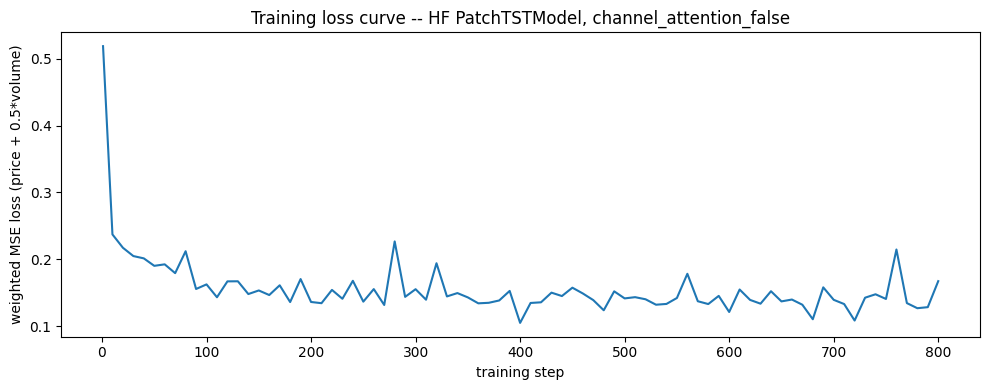

  OHLC RMSE        : 4.9337
  volume RMSE      : 3,686,647.5
  dir acc per bar  : 0.5273 / 0.5436 / 0.5549
  wrote steven/comparison_metrics/hf_patchtst_fused_head-channel_attention_false.json

training channel_attention_true
epoch  1/20  train_loss=0.23116 (price=0.00203, vol=0.45826)  val_loss=0.17028 (price=0.00134, vol=0.33787)
epoch  2/20  train_loss=0.18687 (price=0.00078, vol=0.37218)  val_loss=0.10691 (price=0.00037, vol=0.21307)
epoch  3/20  train_loss=0.16154 (price=0.00027, vol=0.32255)  val_loss=0.09626 (price=0.00017, vol=0.19217)
epoch  4/20  train_loss=0.15253 (price=0.00015, vol=0.30475)  val_loss=0.09680 (price=0.00010, vol=0.19339)
epoch  5/20  train_loss=0.14841 (price=0.00014, vol=0.29655)  val_loss=0.09474 (price=0.00014, vol=0.18919)
epoch  6/20  train_loss=0.14385 (price=0.00012, vol=0.28746)  val_loss=0.09533 (price=0.00011, vol=0.19044)
epoch  7/20  train_loss=0.14238 (price=0.00012, vol=0.28453)  val_loss=0.09493 (price=0.00010, vol=0.18966)
epoch  8/20  train

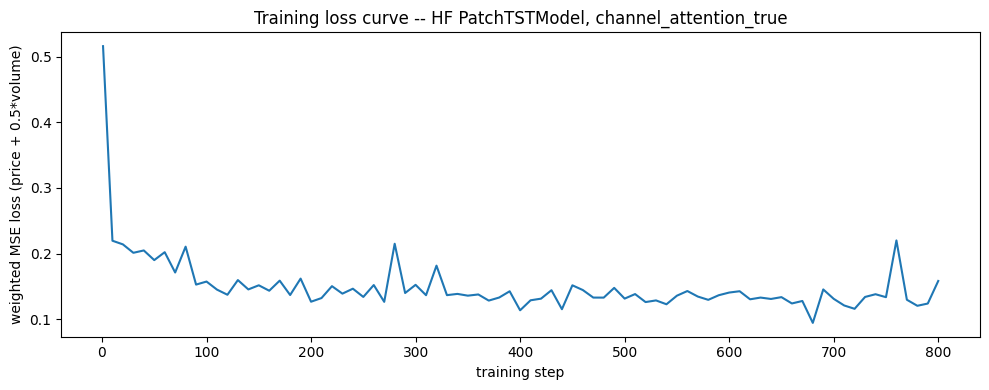

  OHLC RMSE        : 4.8368
  volume RMSE      : 4,007,730.8
  dir acc per bar  : 0.5298 / 0.5407 / 0.5453
  wrote steven/comparison_metrics/hf_patchtst_fused_head-channel_attention_true.json


In [8]:
def run_epoch(model, loader, optimizer, device, train: bool, loss_history=None, step_holder=None, log_every=10):
    model.train(mode=train)
    total, price_total, vol_total, n = 0.0, 0.0, 0.0, 0
    for batch in loader:
        past_values = batch['past_values'].to(device)
        y = batch['y'].to(device)

        with torch.set_grad_enabled(train):
            price, volume = model(past_values)
            loss, parts = weighted_mse_loss(price, volume, y, W_PRICE, W_VOL)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if step_holder is not None:
                step_holder[0] += 1
                if loss_history is not None and (step_holder[0] == 1 or step_holder[0] % log_every == 0):
                    loss_history.append((step_holder[0], float(loss.item())))

        bs = y.shape[0]
        total += loss.item() * bs
        price_total += parts['price_loss'] * bs
        vol_total += parts['vol_loss'] * bs
        n += bs
    return {'loss': total / n, 'price_loss': price_total / n, 'vol_loss': vol_total / n}


def rmse(pred: np.ndarray, true: np.ndarray) -> float:
    return float(np.sqrt(np.mean((pred - true) ** 2)))


def evaluate(model) -> dict:
    model.eval()
    all_true_y, all_pred_y, all_close0 = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            pv = batch['past_values'].to(DEVICE)
            price, volume = model(pv)
            pred_y = torch.cat([price.reshape(price.shape[0], -1), volume], dim=1)
            all_true_y.append(batch['y'].numpy())
            all_pred_y.append(pred_y.cpu().numpy())
            all_close0.append(batch['close_0'])

    true_y = np.concatenate(all_true_y)
    pred_y = np.concatenate(all_pred_y)
    close_0 = np.concatenate(all_close0)
    n = len(true_y)

    true_price = true_y[:, :12].reshape(n, 3, 4)
    pred_price = pred_y[:, :12].reshape(n, 3, 4)
    true_ohlc = reconstruct_prices(true_price, close_0)
    pred_ohlc = reconstruct_prices(pred_price, close_0)
    ohlc_rmse = rmse(pred_ohlc, true_ohlc)

    true_vol_norm = true_y[:, 12:15]
    pred_vol_norm = pred_y[:, 12:15]
    true_vol = reconstruct_volume(true_vol_norm, stats)
    pred_vol = reconstruct_volume(pred_vol_norm, stats)
    vol_rmse = rmse(pred_vol, true_vol)

    true_close_ret = true_price[:, :, 0] + true_price[:, :, 1]
    pred_close_ret = pred_price[:, :, 0] + pred_price[:, :, 1]
    dir_acc = (np.sign(pred_close_ret) == np.sign(true_close_ret)).mean(axis=0)

    return {
        'n_windows': n,
        'ohlc_rmse': ohlc_rmse,
        'volume_rmse': vol_rmse,
        'directional_accuracy': dir_acc.tolist(),
    }


os.makedirs('steven/comparison_metrics', exist_ok=True)
results = {}

for channel_attention in CHANNEL_ATTENTION_SETTINGS:
    setting_key = f'channel_attention_{str(channel_attention).lower()}'
    print(f'\n{"="*70}\ntraining {setting_key}\n{"="*70}')

    # Reset the seed per setting so both runs get identical weight init/dropout draws --
    # data order is already independent of global RNG state (np.random.default_rng(SEED+epoch)
    # below), but model init/dropout use torch's global RNG, which would otherwise have
    # already been advanced by whichever setting trained first.
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = build_model(channel_attention).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    loss_history = []
    step_holder = [0]
    best_val_loss = float('inf')

    for epoch in range(MAX_EPOCHS):
        train_rng = np.random.default_rng(SEED + epoch)
        n_train = min(TRAIN_WINDOWS_PER_EPOCH, len(train_starts_full))
        train_starts = train_rng.choice(train_starts_full, size=n_train, replace=False)
        train_ds = FixedContextDataset(feat, opens, closes, train_starts)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)

        train_metrics = run_epoch(model, train_loader, optimizer, DEVICE, train=True,
                                   loss_history=loss_history, step_holder=step_holder)
        val_metrics = run_epoch(model, val_loader, optimizer, DEVICE, train=False)

        print(f'epoch {epoch+1:2d}/{MAX_EPOCHS}  '
              f'train_loss={train_metrics["loss"]:.5f} (price={train_metrics["price_loss"]:.5f}, vol={train_metrics["vol_loss"]:.5f})  '
              f'val_loss={val_metrics["loss"]:.5f} (price={val_metrics["price_loss"]:.5f}, vol={val_metrics["vol_loss"]:.5f})')

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']

    print(f'done ({setting_key}). best val_loss={best_val_loss:.5f}')

    fig, ax = plt.subplots(figsize=(10, 4))
    steps, losses = zip(*loss_history)
    ax.plot(steps, losses)
    ax.set_xlabel('training step')
    ax.set_ylabel('weighted MSE loss (price + 0.5*volume)')
    ax.set_title(f'Training loss curve -- HF PatchTSTModel, {setting_key}')
    plt.tight_layout()
    plt.show()

    eval_metrics = evaluate(model)
    print(f'  OHLC RMSE        : {eval_metrics["ohlc_rmse"]:.4f}')
    print(f'  volume RMSE      : {eval_metrics["volume_rmse"]:,.1f}')
    dir_acc = eval_metrics['directional_accuracy']
    print(f'  dir acc per bar  : {dir_acc[0]:.4f} / {dir_acc[1]:.4f} / {dir_acc[2]:.4f}')

    output = {
        'experiment': {**EXPERIMENT, 'channel_attention': channel_attention, 'seed': SEED},
        'best_val_loss': best_val_loss,
        **eval_metrics,
    }
    results[setting_key] = output

    out_path = f'steven/comparison_metrics/{EXPERIMENT["name"]}-{setting_key}.json'
    with open(out_path, 'w') as f:
        json.dump(output, f, indent=2)
    print(f'  wrote {out_path}')


## Results summary

In [9]:
print(f'{"setting":<26} {"OHLC RMSE":>10} {"volume RMSE":>14} {"dir acc (bar1/2/3)":>22}')
for setting_key, r in results.items():
    da = r['directional_accuracy']
    print(f'{setting_key:<26} {r["ohlc_rmse"]:>10.4f} {r["volume_rmse"]:>14,.1f} '
          f'{da[0]:>6.4f}/{da[1]:.4f}/{da[2]:.4f}')


setting                     OHLC RMSE    volume RMSE     dir acc (bar1/2/3)
channel_attention_false        4.9337    3,686,647.5 0.5273/0.5436/0.5549
channel_attention_true         4.8368    4,007,730.8 0.5298/0.5407/0.5453


## Caveats and recommended next steps

- **One seed per setting.** `CHANNEL_ATTENTION_SETTINGS` controls which settings get trained
  in this pass -- both by default, so this comparison (channel-independent vs. channel-mixing
  on the identical task/loss/data) is produced in a single run now.
- **Fixed context (70 bars) vs. steven's variable-length curriculum.** Compare against
  steven's "long" bucket, not "overall" -- see the training/evaluation markdown above. If this
  approach looks promising, replicating the curriculum (via HF's `past_observed_mask`
  for left-padding shorter contexts) would be the natural next step, not yet built here.
- **No backtest yet.** `steven/src/evaluate.py`'s long-only limit-order backtest
  (`run_backtest`) is deferred until we've picked the better architecture/`channel_attention`
  setting on the forecasting metrics above.
- **Same loss, but not a perfectly controlled experiment.** `channel_attention` isn't the
  only architectural difference from steven's model -- his early-channel-fusion patch
  embedding and flatten-all-patches head vs. this notebook's channel-independent patching
  and mean-pooled head are both different regardless of the `channel_attention` setting.
  This notebook isolates the *loss/target/data* variable (now identical), not every
  architectural detail.
- **Reusing this notebook for the next experiment ladder step** (drop volume / raw-price
  target / etc.): update `EXPERIMENT["name"]`/`["description"]`/`["target"]`/`["include_volume"]`
  in the imports/config cell, and the model/loss cells as needed -- don't fork a new notebook
  file for it (see `docs/experiments.md`'s header convention).


## Commit + push results

Same pattern as `steven/colab_train.ipynb`'s own commit/push cells -- reused here so every
experiment notebook that runs on a fresh Colab VM handles git auth the same way.


In [10]:
# Fresh Colab VM has no git identity configured -- needed for `commit` to work at all.
# Only sets it for this local clone (no --global), harmless to commit/share.
!git -C {REPO_DIR} config user.email "woodychang891121@gmail.com"
!git -C {REPO_DIR} config user.name "WoodyChang21"

commit_msg = f"chore(model): log {EXPERIMENT['name']} comparison_metrics from this Colab run"

!git add steven/comparison_metrics
!git status
!git commit -m {commit_msg!r}


On branch PatchTST_OLCV
Your branch is up to date with 'origin/PatchTST_OLCV'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   steven/comparison_metrics/hf_patchtst_fused_head-channel_attention_false.json
	new file:   steven/comparison_metrics/hf_patchtst_fused_head-channel_attention_true.json

[PatchTST_OLCV e0a8860] chore(model): log hf_patchtst_fused_head comparison_metrics from this Colab run
 2 files changed, 46 insertions(+)
 create mode 100644 steven/comparison_metrics/hf_patchtst_fused_head-channel_attention_false.json
 create mode 100644 steven/comparison_metrics/hf_patchtst_fused_head-channel_attention_true.json


In [11]:
import getpass

# Fresh Colab VM has no stored GitHub credentials, so a plain `git push` over HTTPS
# can't authenticate. Prompting interactively (getpass masks it, and it's never written
# into this notebook's saved source/outputs) instead of hardcoding a token in a cell --
# a hardcoded token would get committed into git history the moment this notebook is
# pushed, which is a real credential leak. Needs a GitHub Personal Access Token with
# `repo` scope: https://github.com/settings/tokens
token = getpass.getpass("GitHub Personal Access Token: ")
push_url = f"https://{token}@github.com/WoodyChang21/ECE1508_GenAI.git"
!git -C {REPO_DIR} push {push_url} {BRANCH}
del token, push_url  # don't leave it sitting in a notebook-visible variable longer than needed


Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 12 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 1.02 KiB | 1.02 MiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 2 local objects.
To https://github.com/WoodyChang21/ECE1508_GenAI.git
   357293c..e0a8860  PatchTST_OLCV -> PatchTST_OLCV
